In [1]:
!pip install fastf1 scikit-learn pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.6/427.6 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.3 MB/s eta 0:00:00


In [2]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [4]:
import os
import fastf1

# Create cache folder
os.makedirs('/content/cache', exist_ok=True)

# Enable FastF1 cache
fastf1.Cache.enable_cache('/content/cache')

print("Cache enabled successfully!")

Cache enabled successfully!


In [5]:
fastf1.Cache.enable_cache('/content/cache')

In [6]:
session = fastf1.get_session(2024, 'Monza', 'R')

session.load()

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_d

In [7]:
laps = session.laps

laps[['Driver','LapNumber','LapTime']].head()

,Driver,LapNumber,LapTime
0,LEC,1.0,0 days 00:01:28.179000
1,LEC,2.0,0 days 00:01:25.396000
2,LEC,3.0,0 days 00:01:25.179000
3,LEC,4.0,0 days 00:01:24.810000
4,LEC,5.0,0 days 00:01:24.603000


In [8]:
dataset = []

for i, lap in laps.iterlaps():

    try:

        car = lap.get_car_data()

        speed = car['Speed'].mean()

        throttle = car['Throttle'].mean()

        brake = car['Brake'].mean()

        gear = car['nGear'].mean()

        rpm = car['RPM'].mean()

        drs = car['DRS'].mean()

        lap_time = lap['LapTime'].total_seconds()

        dataset.append([

            speed,

            throttle,

            brake,

            gear,

            rpm,

            drs,

            lap_time

        ])

    except:

        continue

In [9]:
df = pd.DataFrame(

dataset,

columns=[

'Speed',

'Throttle',

'Brake',

'nGear',

'RPM',

'DRS',

'LapTime'

]

)

df.head()

,Speed,Throttle,Brake,nGear,RPM,DRS,LapTime
0,221.428994,72.958580,0.189349,5.594675,10467.784024,1.000000,88.179
1,240.671733,75.863222,0.194529,6.045593,10668.133739,1.528875,85.396
2,242.124611,75.725857,0.158879,6.074766,10750.672897,2.473520,85.179
3,243.946372,74.848580,0.179811,6.107256,10738.558360,2.454259,84.810
4,245.437309,75.691131,0.171254,6.143731,10788.844037,2.544343,84.603


In [10]:
print(df.shape)

df.describe()

(1008, 7)


,Speed,Throttle,Brake,nGear,RPM,DRS,LapTime
count,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000
mean,241.354206,74.143574,0.156504,6.166674,10547.936969,0.504710,85.789876
std,10.361500,3.103495,0.020923,0.280613,203.136287,0.852791,4.224563
min,170.462555,56.477212,0.104918,4.482759,9193.627753,0.000000,81.432000
25%,240.317951,72.505878,0.142857,6.125287,10460.681941,0.000000,83.853500
50%,243.159936,74.424179,0.154341,6.229693,10578.570534,0.000000,84.980500
75%,246.524612,76.348173,0.166309,6.308728,10679.631707,1.025357,85.971500
max,254.547855,80.802632,0.323810,6.514851,10890.308869,6.030864,120.178000


In [11]:
X = df[

['Speed',

'Throttle',

'Brake',

'nGear',

'RPM',

'DRS']

]

y = df['LapTime']

In [12]:
X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42

)

In [13]:
model = RandomForestRegressor(

n_estimators=200,

random_state=42

)

model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [14]:
predictions = model.predict(X_test)

predictions[:10]

array([87.73397 , 84.489195, 84.61386 , 84.28808 , 82.2204  , 84.788115,
       84.8798  , 83.87588 , 85.89202 , 83.10598 ])

In [15]:
mae = mean_absolute_error(

y_test,

predictions

)

print("Mean Absolute Error:")

print(mae)

Mean Absolute Error:
0.43598257425743336


In [16]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':model.feature_importances_

})

importance.sort_values(

'Importance',

ascending=False
)

,Feature,Importance
0,Speed,0.921666
4,RPM,0.033306
3,nGear,0.027137
2,Brake,0.011307
1,Throttle,0.005049
5,DRS,0.001536


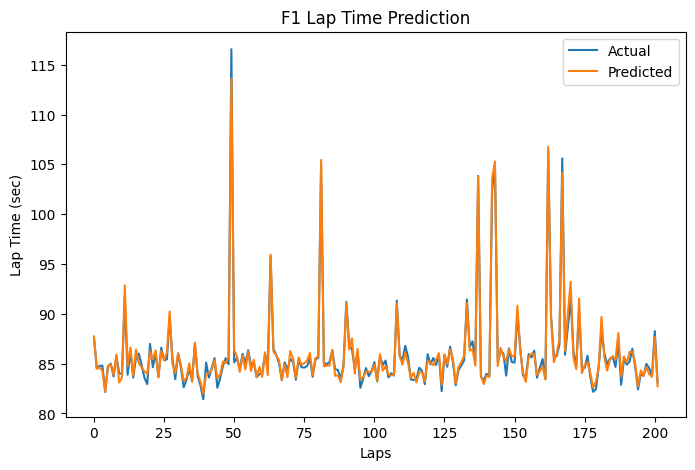

In [17]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values)

plt.plot(predictions)

plt.legend(['Actual','Predicted'])

plt.xlabel("Laps")

plt.ylabel("Lap Time (sec)")

plt.title("F1 Lap Time Prediction")

plt.show()

In [18]:
new_data = [[

250,     # Speed

95,      # Throttle

0,       # Brake

7,       # Gear

11500,   # RPM

1        # DRS

]]

prediction = model.predict(new_data)

print(

"Predicted Lap Time:",

prediction[0],

"seconds"

)

Predicted Lap Time: 82.74677500000003 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
